# **5 CLASS CLASSIFICATION WITH SMOTE**

In [ ]:
# Install SMOTE for balancing the dataset
!pip install imbalanced-learn

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset
from imblearn.over_sampling import SMOTE

## **Data Loading Function**
### This cell defines the paths and the function to load and align your .npy files.

In [ ]:
# Configuration
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped/"
CLASSES = ['AD_graphs', 'CN_graphs', 'EMCI_graphs', 'LMCI_graphs', 'MCI_graphs']

def load_data():
    X_stacked = []
    y_labels = []

    for label in CLASSES:
        p_path = os.path.join(BASE_PATH, label, 'Graph_Output')
        c_path = os.path.join(BASE_PATH, label, 'Graph_Output_Coherence')
        g_path = os.path.join(BASE_PATH, label, 'Graph_Output_Granger')

        if not os.path.exists(p_path):
            print(f"Skipping {label}: Folder not found")
            continue

        files = [f for f in os.listdir(p_path) if f.endswith('.npy')]
        print(f"Loading {len(files)} subjects from {label}...")

        for f in files:
            try:
                # Align the three different graph files
                f_coherence = f.replace('_corr_matrix', '_coherence_matrix')
                f_granger = f.replace('_corr_matrix', '_granger_matrix')

                p_mat = np.load(os.path.join(p_path, f))
                c_mat = np.load(os.path.join(c_path, f_coherence))
                g_mat = np.load(os.path.join(g_path, f_granger))

                # Per-channel normalization
                p_mat = (p_mat - np.mean(p_mat)) / (np.std(p_mat) + 1e-8)
                c_mat = (c_mat - np.mean(c_mat)) / (np.std(c_mat) + 1e-8)
                g_mat = (g_mat - np.mean(g_mat)) / (np.std(g_mat) + 1e-8)

                X_stacked.append(np.stack([p_mat, c_mat, g_mat], axis=0))
                y_labels.append(label)
            except Exception as e:
                continue

    return np.array(X_stacked), np.array(y_labels)

# Execute Loading
X, y = load_data()
print(f"Successfully loaded {len(X)} total samples.")

Loading 26 subjects from AD_graphs...
Loading 59 subjects from CN_graphs...
Loading 28 subjects from EMCI_graphs...
Loading 28 subjects from LMCI_graphs...
Loading 31 subjects from MCI_graphs...
Successfully loaded 172 total samples.


## **Balancing the Dataset (SMOTE)**
### This cell handles the class imbalance by creating synthetic samples for the minority classes.

In [ ]:
# Encode labels to integers
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Flatten 4D data to 2D for SMOTE (Samples, Channels*H*W)
N, C, H, W = X.shape
X_flat = X.reshape(N, -1)

# Apply SMOTE
print("Balancing classes with SMOTE...")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_flat, y_encoded)

# Reshape back to 4D for the CNN
X_res = X_res.reshape(-1, C, H, W)

print(f"Original shape: {X.shape}")
print(f"Balanced shape: {X_res.shape}")
print(f"Classes found: {encoder.classes_}")

Balancing classes with SMOTE...
Original shape: (172, 3, 116, 116)
Balanced shape: (295, 3, 116, 116)
Classes found: ['AD_graphs' 'CN_graphs' 'EMCI_graphs' 'LMCI_graphs' 'MCI_graphs']


In [ ]:
import collections

# Count the occurrences of each class in the balanced labels (y_res)
counts = collections.Counter(y_res)

print("--- Total Subjects per Category after SMOTE ---")
for label_index, count in sorted(counts.items()):
    # Convert the integer index back to the original category name
    class_name = encoder.inverse_transform([label_index])[0]
    print(f"{class_name}: {count}")

# Verify the total size of the balanced dataset
print(f"\nTotal samples in dataset: {len(y_res)}")

--- Total Subjects per Category after SMOTE ---
AD_graphs: 59
CN_graphs: 59
EMCI_graphs: 59
LMCI_graphs: 59
MCI_graphs: 59

Total samples in dataset: 295


## **Model Architecture**
### Define the Neural Network structure.

In [ ]:
class NeuroVistaNet_5Class(nn.Module):
    def __init__(self):
        super(NeuroVistaNet_5Class, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)

        # Linear layer input size calculation: 128 filters * 14x14 feature map
        self.fc1 = nn.Linear(128 * 14 * 14, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

## **Training and Evaluation Loop**
### This cell runs the cross-validation and displays the final accuracy and metrics.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = []
all_true = []
fold_accs = []

print(f"Starting Cross-Validation on {device}...\n")

for fold, (t_idx, v_idx) in enumerate(skf.split(X_res, y_res)):
    # Create Loaders
    train_loader = DataLoader(TensorDataset(torch.Tensor(X_res[t_idx]),
                                            torch.LongTensor(y_res[t_idx])),
                              batch_size=16, shuffle=True)

    model = NeuroVistaNet_5Class().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    # Training Loop
    model.train()
    for epoch in range(50):
        epoch_loss = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        v_x = torch.Tensor(X_res[v_idx]).to(device)
        v_y = torch.LongTensor(y_res[v_idx]).to(device)

        outputs = model(v_x)
        preds = outputs.argmax(dim=1)

        # Collect results
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(v_y.cpu().numpy())

        # Calculate Fold Accuracy
        acc = (preds == v_y).float().mean().item()
        fold_accs.append(acc)

        print(f"Fold {fold+1} Completed | Accuracy: {acc*100:.2f}% | Final Epoch Loss: {epoch_loss/len(train_loader):.4f}")

# --- FINAL SUMMARY REPORT ---
print("\n" + "="*30)
print("      NEUROVISTA FINAL REPORT")
print("="*30)

# Calculate and show Average Accuracy
avg_accuracy = np.mean(fold_accs) * 100
std_accuracy = np.std(fold_accs) * 100

print(f"AVERAGE ACCURACY: {avg_accuracy:.2f}% (+/- {std_accuracy:.2f}%)")
print("="*30)

print("\nDetailed Classification Report:")
print(classification_report(all_true, all_preds, target_names=encoder.classes_))

Starting Cross-Validation on cuda...

Fold 1 Completed | Accuracy: 72.88% | Final Epoch Loss: 0.0040
Fold 2 Completed | Accuracy: 74.58% | Final Epoch Loss: 0.0199
Fold 3 Completed | Accuracy: 86.44% | Final Epoch Loss: 0.0089
Fold 4 Completed | Accuracy: 77.97% | Final Epoch Loss: 0.0258
Fold 5 Completed | Accuracy: 83.05% | Final Epoch Loss: 0.0258

      NEUROVISTA FINAL REPORT
AVERAGE ACCURACY: 78.98% (+/- 5.10%)

Detailed Classification Report:
              precision    recall  f1-score   support

   AD_graphs       0.96      0.90      0.93        59
   CN_graphs       0.57      0.64      0.60        59
 EMCI_graphs       0.90      0.80      0.85        59
 LMCI_graphs       0.79      0.85      0.82        59
  MCI_graphs       0.78      0.76      0.77        59

    accuracy                           0.79       295
   macro avg       0.80      0.79      0.79       295
weighted avg       0.80      0.79      0.79       295



## **Visualizing the Confusion Matrix**
### Run this to see which stages the model is confusing.

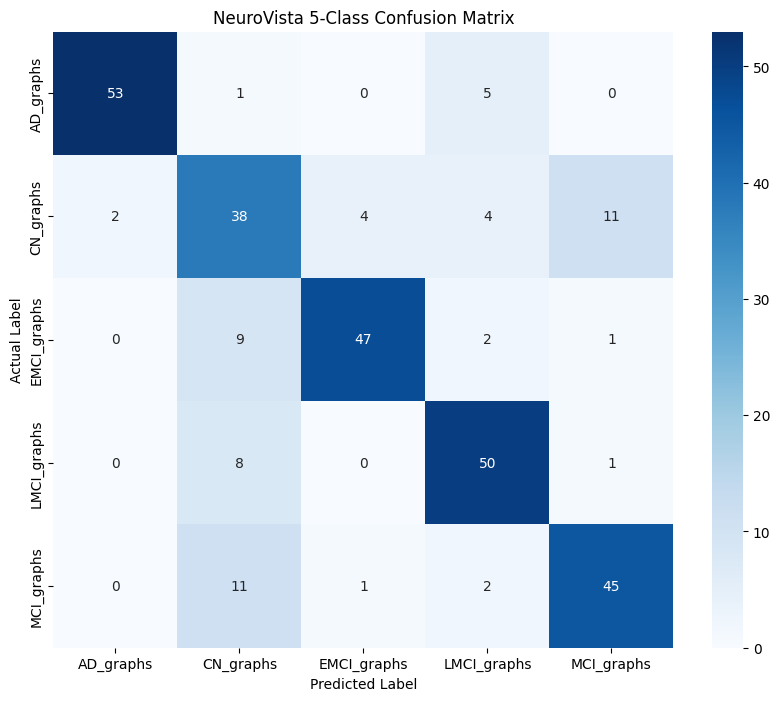

In [ ]:
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('NeuroVista 5-Class Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pickle
import os

# 1. Define your specific path
save_dir = "/content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/5CLASS-MODEL/"

# Create the directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

# 2. Save the Model Weights
# This saves the parameters of the NeuroVistaNet_5Class
model_path = os.path.join(save_dir, "79perc_5class_weights.pth")
torch.save(model.state_dict(), model_path)

# 3. Save the Label Encoder
# Important so you know which index (0-4) corresponds to AD, CN, etc.
encoder_path = os.path.join(save_dir, "79perc_label_encoder.pkl")
with open(encoder_path, 'wb') as f:
    pickle.dump(encoder, f)

# 4. Save a Summary Text File
# Useful for your project documentation
report_path = os.path.join(save_dir, "79perc_performance_report.txt")
with open(report_path, 'w') as f:
    f.write("NEUROVISTA: EARLY DETECTION OF ALZHEIMER'S DISEASE\n")
    f.write("===============================================\n")
    f.write(f"Average Accuracy across 5 folds: {np.mean(fold_accs)*100:.2f}%\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(all_true, all_preds, target_names=encoder.classes_))

print(f"✅ All files successfully stored at: {save_dir}")

✅ All files successfully stored at: /content/drive/MyDrive/NEUROVISTA-PROJECT/OUR-MODELS/5CLASS-MODEL/
